In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [3]:
X = pd.read_csv("ames_X_train.csv")
y = pd.read_csv("ames_y_train.csv")

In [4]:
X.head()
X.shape
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1095 non-null   int64  
 1   MSSubClass     1095 non-null   int64  
 2   MSZoning       1095 non-null   object 
 3   LotFrontage    900 non-null    float64
 4   LotArea        1095 non-null   int64  
 5   Street         1095 non-null   object 
 6   Alley          67 non-null     object 
 7   LotShape       1095 non-null   object 
 8   LandContour    1095 non-null   object 
 9   Utilities      1095 non-null   object 
 10  LotConfig      1095 non-null   object 
 11  LandSlope      1095 non-null   object 
 12  Neighborhood   1095 non-null   object 
 13  Condition1     1095 non-null   object 
 14  Condition2     1095 non-null   object 
 15  BldgType       1095 non-null   object 
 16  HouseStyle     1095 non-null   object 
 17  OverallQual    1095 non-null   int64  
 18  OverallC

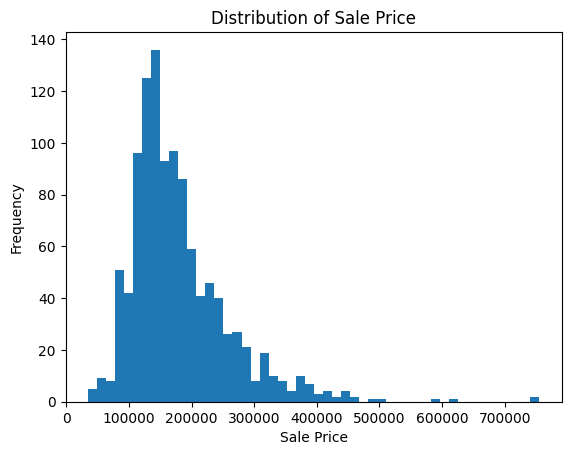

In [5]:
##plotting the distribution of the target variable
plt.hist(y['SalePrice'], bins=50)
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of Sale Price')
plt.show()  

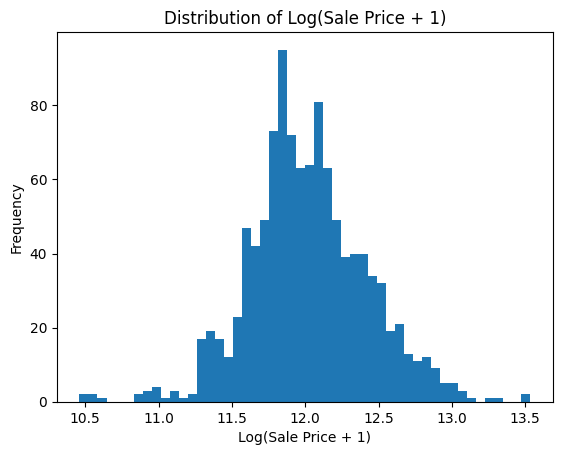

In [6]:
y_log = np.log1p(y)
plt.hist(y_log, bins=50)
plt.xlabel('Log(Sale Price + 1)')
plt.ylabel('Frequency')
plt.title('Distribution of Log(Sale Price + 1)')
plt.show()  

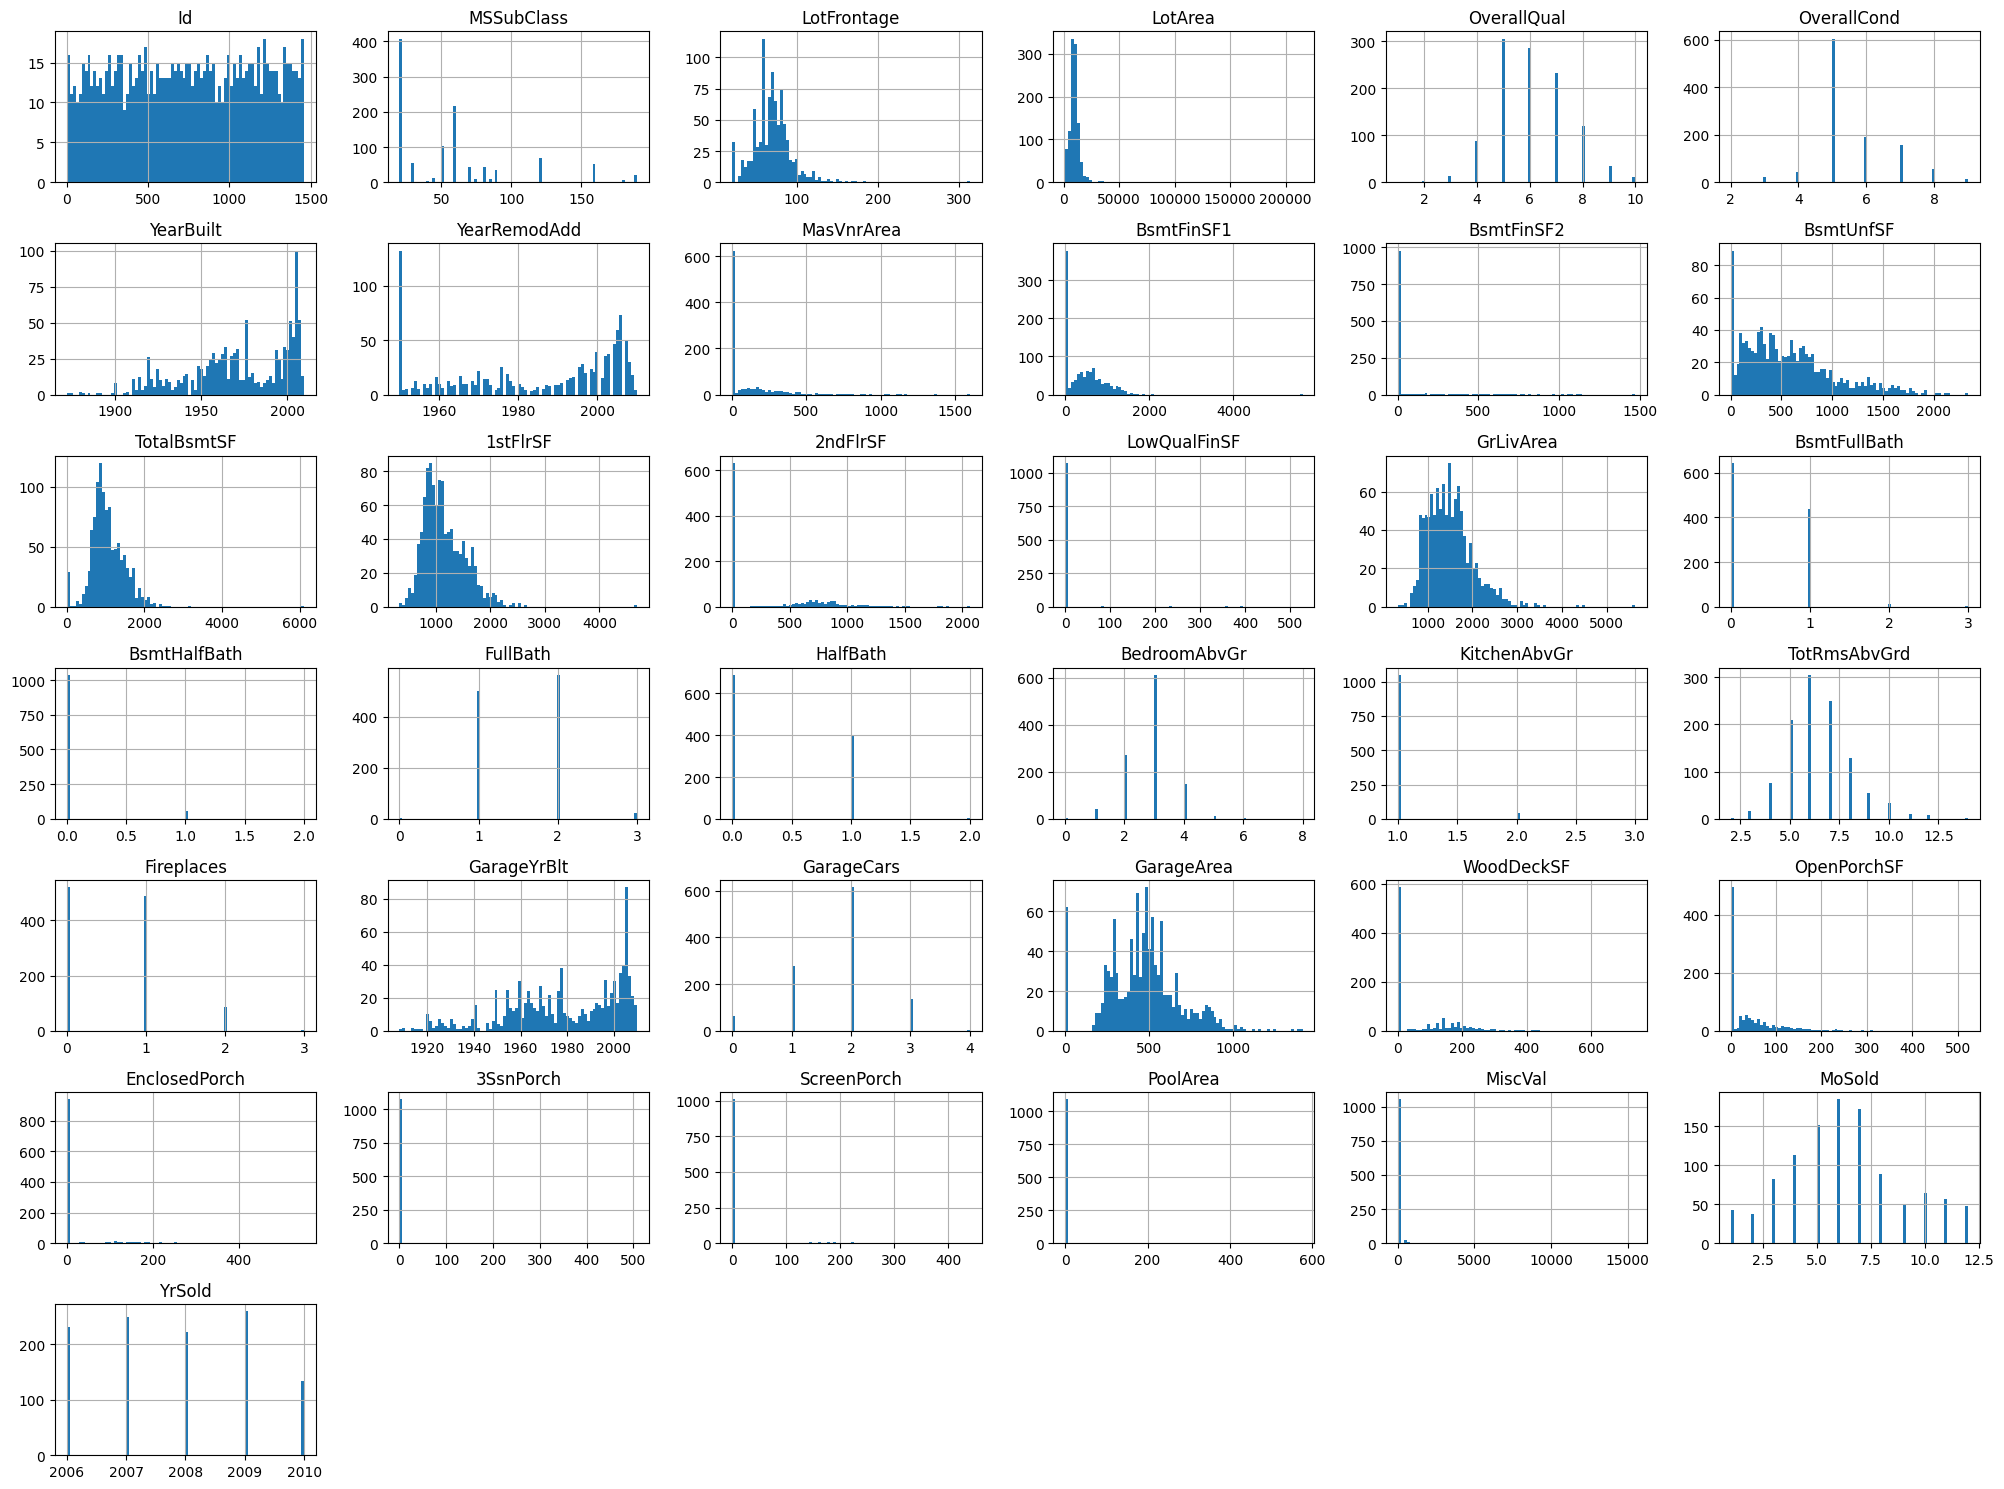

In [7]:
#X["MSSubClass"] = X["MSSubClass"].astype(str)
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns
X[num_cols].hist(figsize=(20, 15), bins=80)
plt.tight_layout()
plt.show()

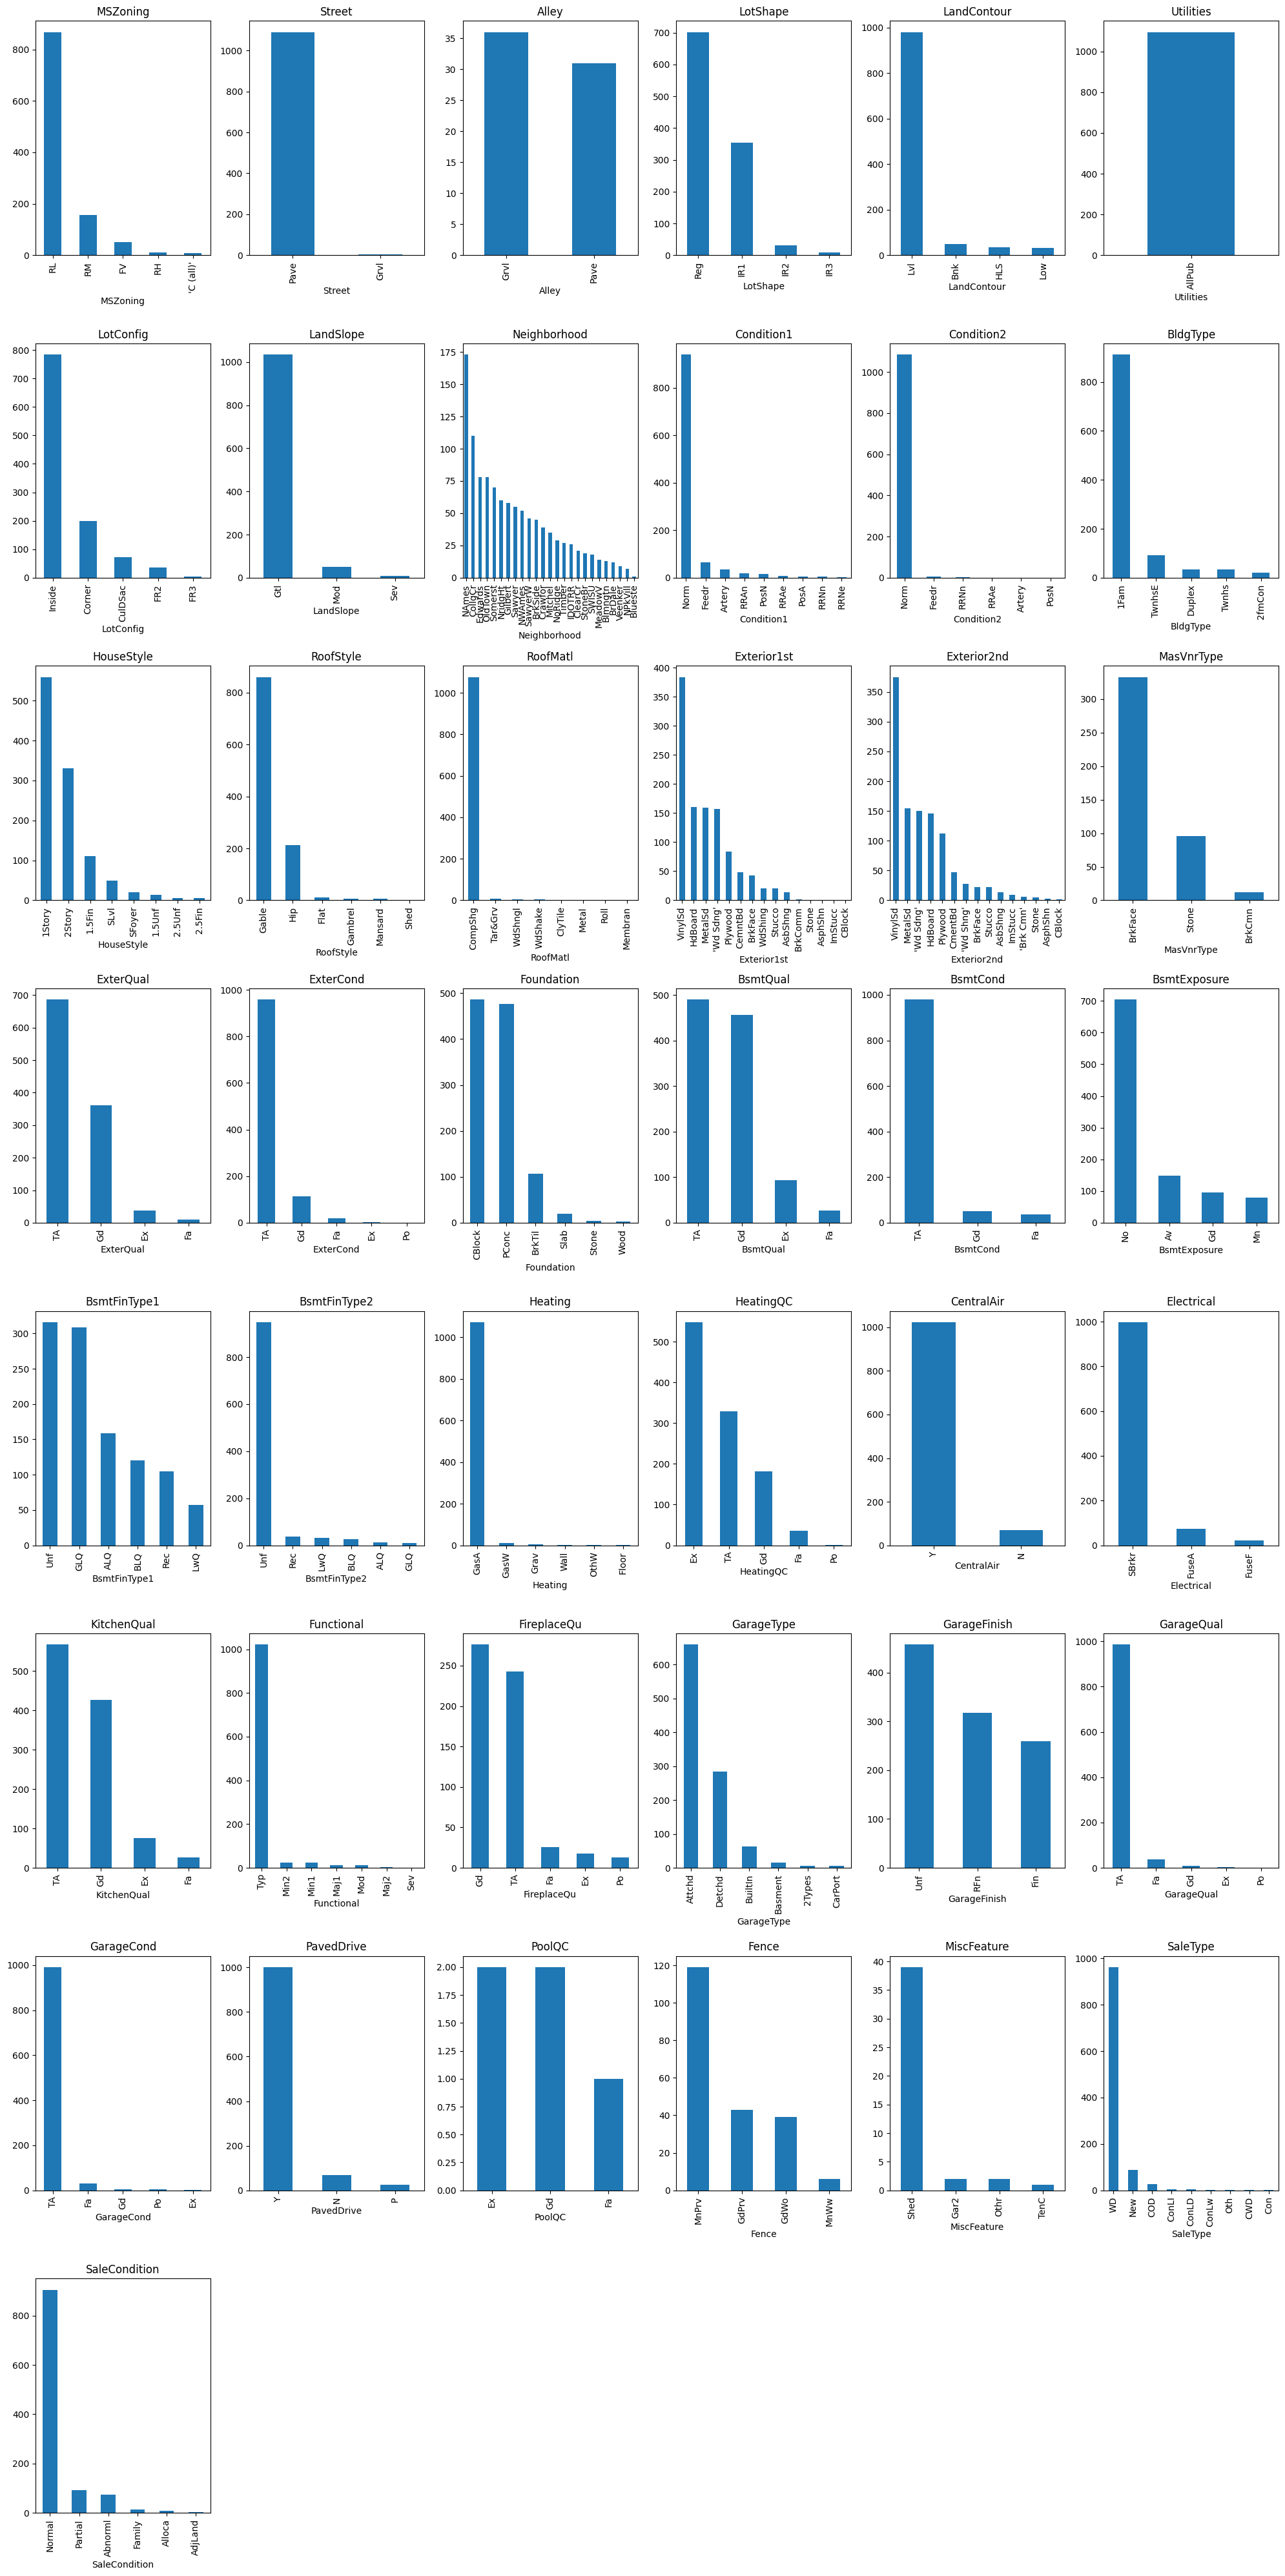

In [8]:
n_cols = 6  # numero colonne per riga
n_rows = int(len(cat_cols) / n_cols) + 1

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    X[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [9]:
y = y["SalePrice"]
y = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The proposed approach relies heavily on extensive feature engineering combined with a regularized linear model (Lasso), which proves effective in capturing the structured relationships present in the Ames dataset.

The transformation pipeline includes domain-driven features (e.g., age, total surface, outdoor score) as well as data-driven feature selection based on correlation and multicollinearity. This allows the model to reduce dimensionality while retaining the most informative variables.

However, some steps—such as correlation-based feature selection and target-based encodings (e.g., NeighborhoodScore)—implicitly use information from the target variable. While this improves predictive performance, it introduces a potential risk of target leakage if not carefully handled within a cross-validation framework.

In this project, these choices are intended to balance model performance and interpretability, acknowledging that the resulting pipeline is relatively complex and may partially overfit to the training data. Nevertheless, the strong empirical results suggest that the combination of structured feature engineering and L1 regularization effectively captures the underlying patterns in the dataset.

Overall, the approach highlights the trade-off between model complexity, interpretability, and generalization, which is particularly relevant in tabular regression problems such as Ames.


In [10]:
class MyTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        X = X.copy()

        # colonne con troppi missing
        missing_pct = X.isnull().mean() * 100
        self.null_cols_ = missing_pct[missing_pct > 80].index.tolist()

        # LotFrontage statistics
        if "Neighborhood" in X.columns and "LotFrontage" in X.columns:
            self.group_stats_ = (
                X.groupby("Neighborhood")["LotFrontage"]
                .median()
                .to_frame(name="median")
            )
            self.stable_neighborhoods_ = self.group_stats_.dropna().index.tolist()
            self.lotfrontage_global_median_ = X["LotFrontage"].median()
        else:
            self.group_stats_ = None
            self.stable_neighborhoods_ = []
            self.lotfrontage_global_median_ = None

        # Outdoor scaler
        self.outdoor_cols_ = [
            "WoodDeckSF",
            "OpenPorchSF",
            "EnclosedPorch",
            "ScreenPorch",
            "3SsnPorch"
        ]
        self.outdoor_cols_ = [c for c in self.outdoor_cols_ if c in X.columns]

        self.scaler_outdoor_ = StandardScaler()
        if self.outdoor_cols_:
            self.scaler_outdoor_.fit(X[self.outdoor_cols_])

        # colonne con troppi zeri
        num_cols = X.select_dtypes(include=["int64", "float64"]).columns
        zero_pct = (X[num_cols] == 0).mean() * 100
        self.cols_high_zero_ = zero_pct[zero_pct > 88].index.tolist()

        # Multicollinearity selection
        self.to_drop_multicollinear_ = []

        if y is not None:
            X_num = X.select_dtypes(include=["int64", "float64"]).copy()
            X_num = X_num.drop(columns=["Id", "SalePrice"], errors="ignore")

            target_corr = X_num.corrwith(y).abs().sort_values(ascending=False)

            corr_matrix = X_num.corr().abs()
            upper = corr_matrix.where(
                np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
            )

            threshold = 0.85
            pairs = upper.stack().sort_values(ascending=False)
            high_corr_pairs = pairs[pairs > threshold]

            to_drop = set()

            for (feat1, feat2), corr_value in high_corr_pairs.items():
                if feat1 in to_drop or feat2 in to_drop:
                    continue

                if target_corr.get(feat1, 0) >= target_corr.get(feat2, 0):
                    to_drop.add(feat2)
                else:
                    to_drop.add(feat1)

            self.to_drop_multicollinear_ = list(to_drop)

        # Target correlation selection
        if y is not None:
            X_num_reduced = X.select_dtypes(include=["int64", "float64"]).copy()
            X_num_reduced = X_num_reduced.drop(columns=["Id", "SalePrice"], errors="ignore")

            final_corr = X_num_reduced.corrwith(y).abs().sort_values(ascending=False)

            threshold_target = 0.2
            selected_num_features = final_corr[final_corr >= threshold_target].index.tolist()

            all_num_features = X_num_reduced.columns.tolist()
            self.num_to_drop_low_corr_ = [
                c for c in all_num_features
                if c not in selected_num_features
            ]
        else:
            self.num_to_drop_low_corr_ = []

        # NeighborhoodScore
        if y is not None and "Neighborhood" in X.columns:
            self.neigh_mean_ = y.groupby(X["Neighborhood"]).mean()
            self.global_target_mean_ = y.mean()
        else:
            self.neigh_mean_ = None
            self.global_target_mean_ = None

        # Rare Exterior1st categories
        if "Exterior1st" in X.columns:
            freq = X["Exterior1st"].value_counts()
            self.rare_exterior1st_ = freq[freq < 10].index.tolist()
        else:
            self.rare_exterior1st_ = []

        return self

    def transform(self, X):
        X = X.copy()

        # Drop columns with too many missing values
        X = X.drop(columns=self.null_cols_, errors="ignore")

        # Basic imputations
        cat_none = [
            "FireplaceQu",
            "GarageType", "GarageFinish", "GarageQual", "GarageCond",
            "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
            "MasVnrType"
        ]

        num_zero = [
            "GarageYrBlt", "GarageCars", "GarageArea",
            "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
            "BsmtFullBath", "BsmtHalfBath",
            "MasVnrArea"
        ]

        for col in cat_none:
            if col in X.columns:
                X[col] = X[col].fillna("None")

        for col in num_zero:
            if col in X.columns:
                X[col] = X[col].fillna(0)

        # Smart imputation LotFrontage
        if (
            self.group_stats_ is not None
            and "LotFrontage" in X.columns
            and "Neighborhood" in X.columns
        ):
            neighborhood_median = X["Neighborhood"].map(self.group_stats_["median"])

            mask = (
                X["LotFrontage"].isnull()
                & X["Neighborhood"].isin(self.stable_neighborhoods_)
            )

            X.loc[mask, "LotFrontage"] = neighborhood_median[mask]
            X["LotFrontage"] = X["LotFrontage"].fillna(self.lotfrontage_global_median_)

        # Age features
        if all(col in X.columns for col in ["YrSold", "YearBuilt"]):
            X["HouseAge"] = X["YrSold"] - X["YearBuilt"]

        if all(col in X.columns for col in ["YrSold", "YearRemodAdd"]):
            X["RemodAge"] = X["YrSold"] - X["YearRemodAdd"]

        if all(col in X.columns for col in ["YearRemodAdd", "YearBuilt"]):
            X["IsRemodeled"] = (X["YearRemodAdd"] != X["YearBuilt"]).astype(int)

        if "GarageYrBlt" in X.columns:
            X["HasGarage"] = ((~X["GarageYrBlt"].isna()) & (X["GarageYrBlt"] > 0)).astype(int)

        if all(col in X.columns for col in ["YrSold", "GarageYrBlt", "HasGarage"]):
            X["GarageAge"] = np.where(
                X["HasGarage"] == 1,
                X["YrSold"] - X["GarageYrBlt"],
                0
            )
            X["GarageAge"] = X["GarageAge"].clip(lower=0)

        X = X.drop(
            columns=["GarageYrBlt", "YrSold", "YearRemodAdd", "HasGarage", "MoSold"],
            errors="ignore"
        )

        # TotalSF
        sf_cols = ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"]

        if all(col in X.columns for col in sf_cols):
            X["TotalSF"] = (
                X["TotalBsmtSF"] +
                X["1stFlrSF"] +
                X["2ndFlrSF"]
            )

        X = X.drop(columns=sf_cols, errors="ignore")

        # OutdoorScore
        if self.outdoor_cols_ and all(col in X.columns for col in self.outdoor_cols_):
            outdoor_scaled = self.scaler_outdoor_.transform(X[self.outdoor_cols_])

            outdoor_scaled = pd.DataFrame(
                outdoor_scaled,
                columns=self.outdoor_cols_,
                index=X.index
            )

            X["OutdoorScore"] = (
                0.33 * outdoor_scaled["WoodDeckSF"] +
                0.32 * outdoor_scaled["OpenPorchSF"] -
                0.17 * outdoor_scaled["EnclosedPorch"] +
                0.10 * outdoor_scaled["ScreenPorch"] +
                0.07 * outdoor_scaled["3SsnPorch"]
            )

        X = X.drop(columns=self.outdoor_cols_, errors="ignore")

        # Bathroom features
        bath_cols = ["FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"]

        if all(col in X.columns for col in ["FullBath", "HalfBath"]):
            X["TotalBaths"] = (
                0.58 * X["FullBath"] +
                0.38 * X["HalfBath"]
            )

        if all(col in X.columns for col in ["BsmtFullBath", "BsmtHalfBath"]):
            X["TotalBsmtBaths"] = (
                0.23 * X["BsmtFullBath"] +
                0.03 * X["BsmtHalfBath"]
            )

        X = X.drop(columns=bath_cols, errors="ignore")

        # NeighborhoodScore
        if self.neigh_mean_ is not None and "Neighborhood" in X.columns:
            X["NeighborhoodScore"] = X["Neighborhood"].map(self.neigh_mean_)
            X["NeighborhoodScore"] = X["NeighborhoodScore"].fillna(self.global_target_mean_)

        # Exterior1st / Exterior2nd
        if "Exterior1st" in X.columns and "Exterior2nd" in X.columns:
            X["HasMixedExterior"] = (
                X["Exterior1st"] != X["Exterior2nd"]
            ).astype(int)

            X = X.drop(columns=["Exterior2nd"], errors="ignore")

            X["Exterior1st"] = X["Exterior1st"].replace(
                self.rare_exterior1st_,
                "Other"
            )

        # MasVnrType
        if "MasVnrType" in X.columns:
            X["HasMasVnr"] = (X["MasVnrType"] != "None").astype(int)
            X = X.drop(columns=["MasVnrType"], errors="ignore")

        # RoofStyle
        if "RoofStyle" in X.columns:
            X["IsHipRoof"] = (X["RoofStyle"] == "Hip").astype(int)
            X = X.drop(columns=["RoofStyle"], errors="ignore")

        # Basement + Heating + Electrical
        qual_map = {
            "Ex": 5,
            "Gd": 4,
            "TA": 3,
            "Fa": 2,
            "Po": 1,
            "None": 0
        }

        exposure_map = {
            "Gd": 4,
            "Av": 3,
            "Mn": 2,
            "No": 1,
            "None": 0
        }

        for col in ["HeatingQC", "BsmtQual", "BsmtCond"]:
            if col in X.columns:
                X[col + "_num"] = X[col].map(qual_map)

        if "Electrical" in X.columns:
            X["IsModernElectrical"] = (X["Electrical"] == "SBrkr").astype(int)

        if "BsmtExposure" in X.columns:
            X["BsmtExposure_num"] = X["BsmtExposure"].map(exposure_map)

        if "BsmtFinType1" in X.columns and "BsmtFinType2" in X.columns:
            X["HasSecondBsmtType"] = (
                X["BsmtFinType1"] != X["BsmtFinType2"]
            ).astype(int)

            bsmt_type_map = {
                "GLQ": "Good",
                "ALQ": "Good",
                "BLQ": "Average",
                "Rec": "Average",
                "LwQ": "Low",
                "Unf": "Unf",
                "None": "None"
            }

            X["BsmtFinType1_simple"] = X["BsmtFinType1"].replace(bsmt_type_map)

        # Location
        def map_location(value):
            if value in ["PosN", "PosA"]:
                return 1
            elif value in ["Artery", "RRAn"]:
                return -1
            else:
                return 0

        if "Condition1" in X.columns:
            X["LocationScore"] = X["Condition1"].apply(map_location)

        # Building type
        if "BldgType" in X.columns:
            X["IsSingleFamily"] = (X["BldgType"] == "1Fam").astype(int)

        # Drop original categorical columns already encoded manually
        cols_to_drop_cat = [
            "BsmtQual",
            "BsmtCond",
            "BsmtExposure",
            "BsmtFinType1",
            "BsmtFinType2",
            "HeatingQC",
            "Electrical",
            "Condition1",
            "BldgType"
        ]

        X = X.drop(columns=cols_to_drop_cat, errors="ignore")

        # Drop columns selected during fit
        X = X.drop(columns=self.cols_high_zero_, errors="ignore")
        X = X.drop(columns=self.to_drop_multicollinear_, errors="ignore")
        X = X.drop(columns=self.num_to_drop_low_corr_, errors="ignore")

        return X

In [11]:
preprocessing = ColumnTransformer([
    ("num", StandardScaler(), make_column_selector(dtype_include=np.number)),
    ("cat", OneHotEncoder(handle_unknown="ignore"), make_column_selector(dtype_include=object))
])
#########LINEAR REGRESSION EASY
pipeline = Pipeline([
    ("custom", MyTransformer()),
    ("preprocessing", preprocessing),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)

In [12]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error
pipeline.set_params(
    model=LassoCV(
        alphas=None,        # fa lui la griglia
        cv=5,
        random_state=42,
        max_iter=10000
    )
)

pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)

rmse_log = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE (log) Lasso:", rmse_log)

pred_real = np.expm1(pred)
y_test_real = np.expm1(y_test)

rmse_real = np.sqrt(mean_squared_error(y_test_real, pred_real))
print("RMSE reale Lasso:", rmse_real)

RMSE (log) Lasso: 0.11698605051232047
RMSE reale Lasso: 25359.454364356694


In [13]:
from sklearn.linear_model import ElasticNetCV

pipeline.set_params(
    model=ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 1.0],
        cv=5,
        random_state=42,
        max_iter=10000
    )
)

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)

rmse_log = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE (log) Elastic Net:", rmse_log)

RMSE (log) Elastic Net: 0.11698605051232047


In [14]:
hidden_test = pd.read_csv("ames_X_test.csv")
hidden_test.head()
hidden_test.shape


(365, 80)

In [15]:
pred_log = pipeline.predict(hidden_test)
pred_real = np.expm1(pred_log)

pd.DataFrame(pred_real).to_csv(
    "predictions.txt",
    index=False,
    header=False
)

In [16]:
submission = pd.DataFrame({
    "Id": hidden_test["Id"],
    "SalePrice": pred_real
})

submission.to_csv("DiMarco_ames_predictions.csv", index=False)